## Clone the Repository and Install Requirements

In [14]:
!nvidia-smi

Sat Apr  5 16:51:18 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!git clone https://github.com/Hyperakan/fasterrcnn-pytorch-training-pipeline.git

fatal: destination path 'fastercnn-pytorch-training-pipeline' already exists and is not an empty directory.


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Enter the repo directory.
%cd /content/fastercnn-pytorch-training-pipeline/

/content/fastercnn-pytorch-training-pipeline


In [5]:

# Install the Requirements
!pip install -r requirements.txt

## Download the Dataset

Here we are using the [Aquarium Dataset](https://public.roboflow.com/object-detection/aquarium) from Roboflow.

Download the unzip the dataset to `custom_data` directory.

In [6]:
!curl -L "https://app.roboflow.com/ds/HZChnBy2Jc?key=qCSuWDeER4" > roboflow.zip; unzip roboflow.zip -d custom_data; rm roboflow.zip

Streaming output truncated to the last 5000 lines.
  inflating: custom_data/train/normal-kidney-48-_jpg.rf.69c92133960796edede229a42b06b604.xml  
 extracting: custom_data/train/normal-kidney-48-_jpg.rf.70b0059e4f9bd26690da6c58cc4248d0.jpg  
  inflating: custom_data/train/normal-kidney-48-_jpg.rf.70b0059e4f9bd26690da6c58cc4248d0.xml  
 extracting: custom_data/train/normal-kidney-48-_jpg.rf.92609462880ed6d31f5f8dd11f877af9.jpg  
  inflating: custom_data/train/normal-kidney-48-_jpg.rf.92609462880ed6d31f5f8dd11f877af9.xml  
 extracting: custom_data/train/normal-kidney-48-_jpg.rf.cefa7202357c133d670f02be86fa5b35.jpg  
  inflating: custom_data/train/normal-kidney-48-_jpg.rf.cefa7202357c133d670f02be86fa5b35.xml  
 extracting: custom_data/train/normal-kidney-48-_rotated_180_jpg.rf.3c02ed24f4a4cd26cfa7aa7c312c1a18.jpg  
  inflating: custom_data/train/normal-kidney-48-_rotated_180_jpg.rf.3c02ed24f4a4cd26cfa7aa7c312c1a18.xml  
 extracting: custom_data/train/normal-kidney-48-_rotated_180_jpg.rf.59

## Create the Custom Dataset YAML File.

In [7]:
%%writefile data_configs/custom_data.yaml
# Images and labels direcotry should be relative to train.py
TRAIN_DIR_IMAGES: 'custom_data/train'
TRAIN_DIR_LABELS: 'custom_data/train'
VALID_DIR_IMAGES: 'custom_data/valid'
VALID_DIR_LABELS: 'custom_data/valid'

# Class names.
CLASSES: [
    '__background__',
    'kidney-stone', 'normal kidney'
]

# Number of classes (object classes + 1 for background class in Faster RCNN).
NC: 3

# Whether to save the predictions of the validation set while training.
SAVE_VALID_PREDICTION_IMAGES: True

Writing data_configs/custom_data.yaml


## Training

In [12]:
!python train.py --data data_configs/custom_data.yaml --epochs 20 --model fasterrcnn_resnet50_fpn_v2 --name custom_training --batch 32

import os
from google.colab import files

# Define the source directory
source_dir = "/content/fastercnn-pytorch-training-pipeline/outputs"  # Replace with your actual runs directory

# Create a zip file of the directory
!zip -r /content/fastercnn-pytorch-training-pipeline/outputs.zip {source_dir}

# Download the zip file
files.download("/content/fastercnn-pytorch-training-pipeline/outputs.zip")

2025-04-05 16:36:29.681671: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743870989.702410   23408 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743870989.708586   23408 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-05 16:36:29.729835: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Not using distributed mode
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core f

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Visualize Validation Results

In [ ]:
import matplotlib.pyplot as plt
import glob as glob

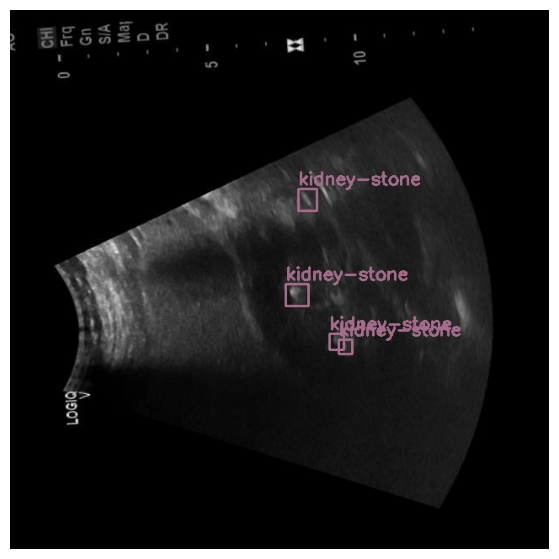

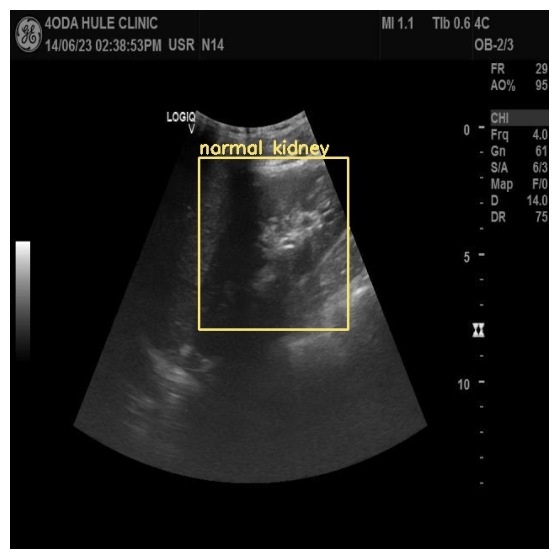

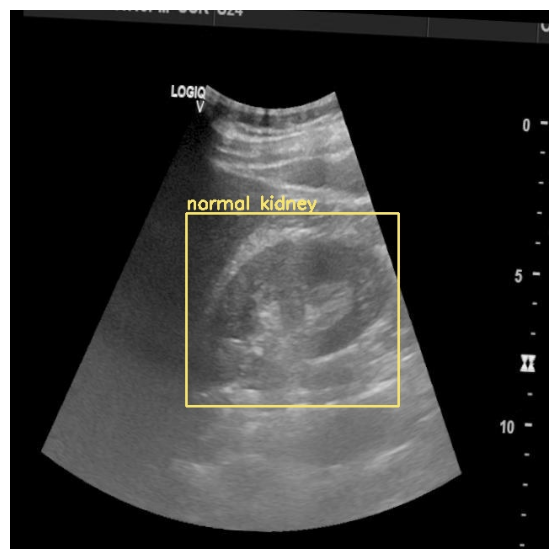

In [ ]:
results_dir_path = '/content/fastercnn-pytorch-training-pipeline/outputs/training/custom_training'
valid_images = glob.glob(f"{results_dir_path}/*.jpg")

for i in range(3):
    plt.figure(figsize=(10, 7))
    image = plt.imread(valid_images[i])
    plt.imshow(image)
    plt.axis('off')
    plt.show()

Check Out the Repo for Latest Updates
https://github.com/sovit-123/fastercnn-pytorch-training-pipeline

## Evaluation

In [15]:

!python eval.py --weights /content/drive/MyDrive/443_modeller/fasterrcnn_resnet50/best_model.pth --data data_configs/custom_data.yaml --model fasterrcnn_resnet50_fpn_v2 --verbose

2025-04-05 16:52:26.173405: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743871946.194507   27462 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743871946.200847   27462 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-05 16:52:26.222507: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Checking Labels and images...
100% 544/544 [00:00<00:00, 13845.02it/s]
Removed 0 problematic images and annotations.


In [ ]:
!python measure_inference_time.py --weights /content/drive/MyDrive/443_modeller/fasterrcnn_resnet50/best_model.pth --data data_configs/custom_data.yaml --model fasterrcnn_resnet50_fpn_v2

2025-04-03 12:58:38.976543: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743685119.008603    3409 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743685119.014888    3409 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-03 12:58:39.036075: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch

In [8]:
!python /content/fastercnn-pytorch-training-pipeline/plot_metrics.py --weights /content/drive/MyDrive/443_modeller/fasterrcnn_resnet50/best_model.pth --data data_configs/custom_data.yaml --model fasterrcnn_resnet50_fpn_v2

Checking Labels and images...
100% 544/544 [00:00<00:00, 13719.90it/s]
Removed 0 problematic images and annotations.
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth
100% 167M/167M [00:00<00:00, 185MB/s]
Evaluating model...
100% 544/544 [01:07<00:00,  8.11it/s]

Maximum Values:
Max Precision: 0.6887
Max Recall: 0.9071
Max F1 Score: 0.5275

Optimal Threshold (based on F1 score): 0.60
At optimal threshold:
Precisi

# fasterrcnn_mobilenetv3_large_fpn training

In [ ]:
!python /content/fastercnn-pytorch-training-pipeline/train.py --model fasterrcnn_mobilenetv3_large_fpn --data data_configs/custom_data.yaml --epochs 20 --batch 24 --imgsz 640 --lr 0.001 --use-train-aug --cosine-annealing --amp --name mobilenetv3_large_fpn_a100_training

2025-04-04 10:42:23.634539: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-04 10:42:23.652932: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743763343.675039   10020 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743763343.681806   10020 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-04 10:42:23.704195: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [ ]:
import os
from google.colab import files

# Define the source directory
source_dir = "/content/fastercnn-pytorch-training-pipeline/outputs"  # Replace with your actual runs directory

# Create a zip file of the directory
!zip -r /content/fastercnn-pytorch-training-pipeline/outputs.zip {source_dir}

# Download the zip file
files.download("/content/fastercnn-pytorch-training-pipeline/outputs.zip")

  adding: content/fastercnn-pytorch-training-pipeline/outputs/ (stored 0%)
  adding: content/fastercnn-pytorch-training-pipeline/outputs/training/ (stored 0%)
  adding: content/fastercnn-pytorch-training-pipeline/outputs/training/mobilenetv3_large_fpn_a100_training/ (stored 0%)
  adding: content/fastercnn-pytorch-training-pipeline/outputs/training/mobilenetv3_large_fpn_a100_training/opt.yaml (deflated 41%)
  adding: content/fastercnn-pytorch-training-pipeline/outputs/training/mobilenetv3_large_fpn_a100_training/events.out.tfevents.1743763389.91dbed1666f7.10020.0 (deflated 52%)
  adding: content/fastercnn-pytorch-training-pipeline/outputs/training/mobilenetv3_large_fpn_a100_training/train.log (deflated 84%)
  adding: content/fastercnn-pytorch-training-pipeline/outputs/training/mobilenetv3_large_fpn_a100_training/image_8_1.jpg (deflated 11%)
  adding: content/fastercnn-pytorch-training-pipeline/outputs/training/mobilenetv3_large_fpn_a100_training/image_11_1.jpg (deflated 10%)
  adding: c

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Verbose mAP.
!python eval.py --weights /content/drive/MyDrive/443_modeller/fasterrcnn_mobilenet/best_model.pth --data data_configs/custom_data.yaml --model fasterrcnn_mobilenetv3_large_fpn --verbose


2025-04-04 11:58:35.009509: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-04 11:58:35.028254: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743767915.050859   29257 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743767915.057816   29257 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-04 11:58:35.080394: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

# FasterRCNN Resnet 18 Training

In [ ]:
!python /content/fastercnn-pytorch-training-pipeline/train.py --model fasterrcnn_resnet18 --data data_configs/custom_data.yaml --epochs 20 --batch 48 --imgsz 640 --lr 0.002 --use-train-aug --cosine-annealing --amp --name resnet18_training
import os
from google.colab import files

# Define the source directory
source_dir = "/content/fastercnn-pytorch-training-pipeline/outputs"  # Replace with your actual runs directory

# Create a zip file of the directory
!zip -r /content/fastercnn-pytorch-training-pipeline/outputs.zip {source_dir}

# Download the zip file
files.download("/content/fastercnn-pytorch-training-pipeline/outputs.zip")


2025-04-04 21:33:22.031152: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-04 21:33:22.048901: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743802402.071188    3751 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743802402.077993    3751 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-04 21:33:22.100291: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Verbose mAP.
!python eval.py --weights /content/drive/MyDrive/443_modeller/fasterrcnn_resnet18/best_model.pth --data data_configs/custom_data.yaml --model fasterrcnn_resnet18 --verbose


2025-04-04 22:34:35.887505: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-04 22:34:35.905457: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743806075.927043   19804 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743806075.933692   19804 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-04 22:34:35.955819: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [ ]:

!python /content/fastercnn-pytorch-training-pipeline/train.py --model fasterrcnn_resnet18 --data data_configs/custom_data.yaml --epochs 20 --batch 48 --imgsz 640 --lr 0.002  --cosine-annealing --amp --name resnet18_training_without_aug

import shutil
import os
source_dir = "/content/fastercnn-pytorch-training-pipeline/outputs"

!zip -r /content/fastercnn-pytorch-training-pipeline/outputs.zip {source_dir}

source_file = "/content/fastercnn-pytorch-training-pipeline/outputs.zip"

destination_dir = "/content/drive/MyDrive/outputs.zip"

shutil.copy(source_file, destination_dir)

os.kill(os.getpid(), 9)  # Forcefully kill the current process (shutdown Colab)


2025-04-04 22:39:11.682808: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-04 22:39:11.701893: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743806351.725123   21089 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743806351.732309   21089 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-04 22:39:11.755168: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr